In [8]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from empiricaldist import Pmf
import matplotlib.pyplot as plt
import seaborn as sns
from utils import decorate

sns.set_style('darkgrid')

## 11.2 How Tall Is A?

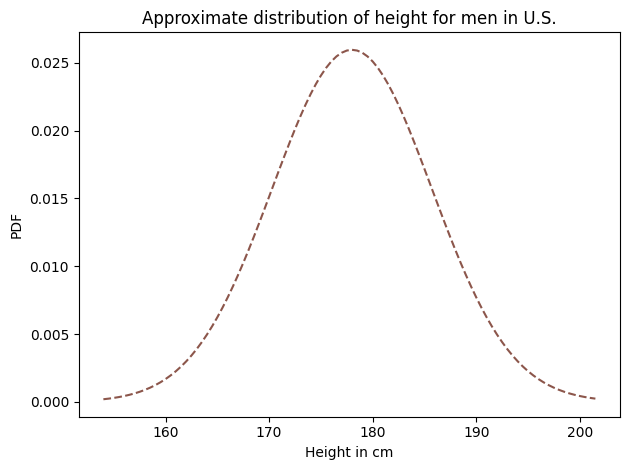

In [5]:
mean = 178
std = 7.7

qs = np.arange(mean-24, mean+24, 0.5)
ps = norm(mean, std).pdf(qs)

prior = Pmf(ps, qs)
prior.normalize()

prior.plot(style='--', color='C5')

decorate(
    xlabel='Height in cm',
    ylabel='PDF',
    title='Approximate distribution of height for men in U.S.'
)

## 11.3 Joint Distribution

In [7]:
def make_joint(pmf1, pmf2):
    """Compute the outer product of two Pmfs."""
    X, Y = np.meshgrid(pmf1, pmf2)
    return pd.DataFrame(X * Y, columns=pmf1.qs, index=pmf2.qs)

joint = make_joint(prior, prior)
print(joint.shape)
print(joint.sum().sum())

(96, 96)
1.0


## 11.4 Visualizing the Joint Distribution

/Users/peiyixu/Desktop/work/duke/FINTECH590/think-bayes/utils.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


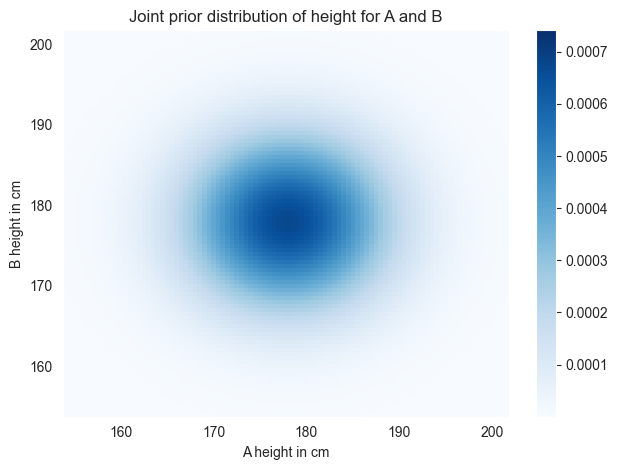

In [9]:
def plot_joint(joint, cmap='Blues'):
    """Plot a joint distribution with a color mesh."""
    vmax = joint.to_numpy().max() * 1.1
    plt.pcolormesh(
        joint.columns, 
        joint.index, 
        joint, 
        cmap=cmap,
        vmax=vmax,
        shading='nearest'
    )
    plt.colorbar()
    
    decorate(
        xlabel='A height in cm',
        ylabel='B height in cm'
    )

plot_joint(joint)
decorate(title='Joint prior distribution of height for A and B')

/Users/peiyixu/Desktop/work/duke/FINTECH590/think-bayes/utils.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


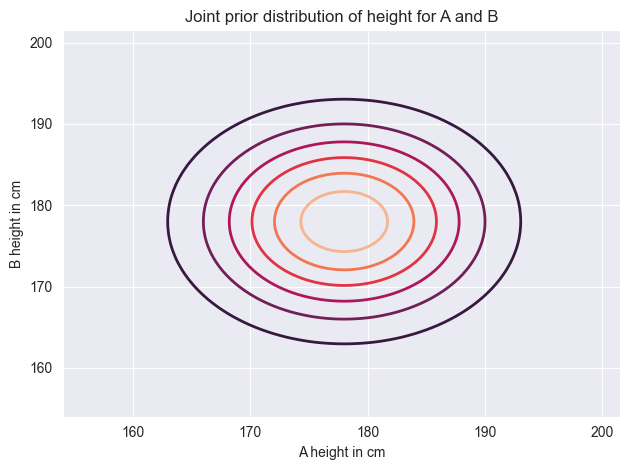

In [10]:
def plot_contour(joint):
    """Plot a joint distribution with a contour."""
    plt.contour(
        joint.columns, 
        joint.index, 
        joint,
        linewidths=2
    )
    decorate(
        xlabel='A height in cm',
        ylabel='B height in cm'
    )

plot_contour(joint)
decorate(title='Joint prior distribution of height for A and B')

## 11.5 Likelihood

/Users/peiyixu/Desktop/work/duke/FINTECH590/think-bayes/utils.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


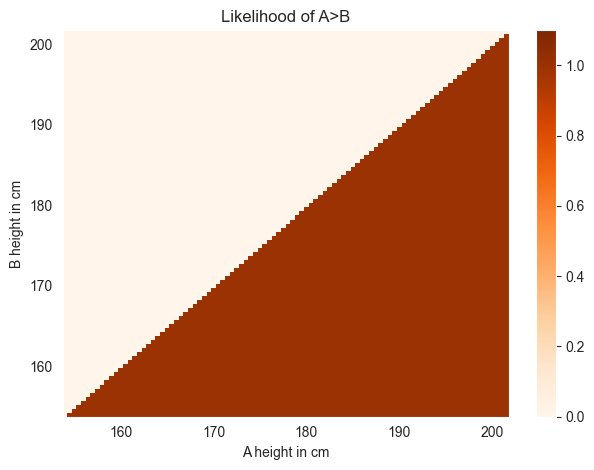

In [13]:
x = joint.columns
y = joint.index
X, Y = np.meshgrid(x, y)

A_taller = (X > Y)
likelihood = np.where(A_taller, 1, 0)
likelihood = pd.DataFrame(likelihood, index=x, columns=y)

plot_joint(likelihood, cmap='Oranges')
decorate(title='Likelihood of A>B')

## 11.6 The Update

/Users/peiyixu/Desktop/work/duke/FINTECH590/think-bayes/utils.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


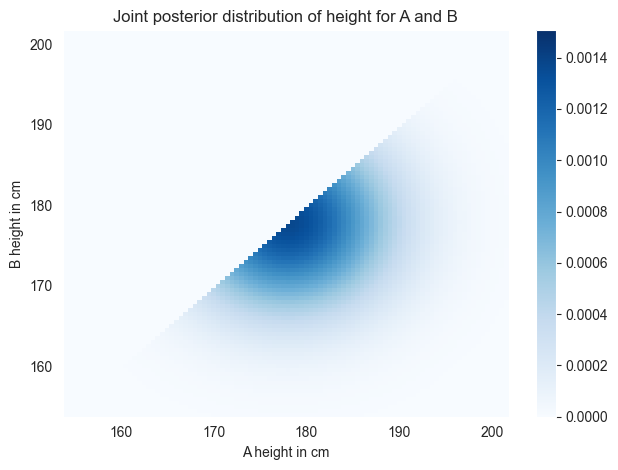

In [14]:
def normalize(joint):
    """Normalize a joint distribution."""
    joint = joint.copy()
    prob_data = joint.to_numpy().sum()
    joint /= prob_data
    return joint


posterior = joint * likelihood
posterior = normalize(posterior)

plot_joint(posterior)
decorate(title='Joint posterior distribution of height for A and B')

## 11.7 Marginal Distributions

In [17]:
marginal_A = posterior.sum(axis=0)
marginal_A = Pmf(marginal_a)

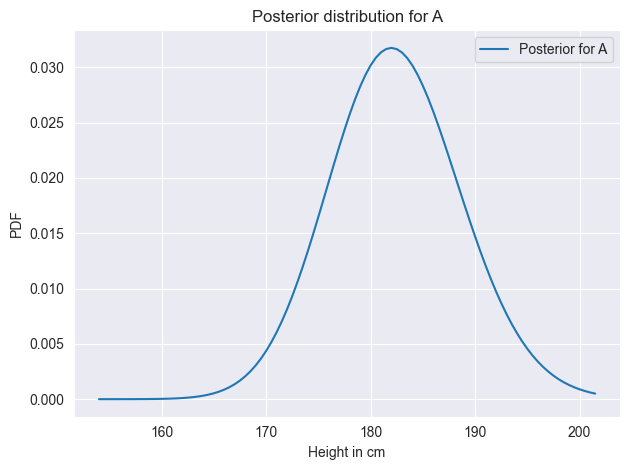

In [18]:
marginal_A.plot(label='Posterior for A')

decorate(
    xlabel='Height in cm',
    ylabel='PDF',
    title='Posterior distribution for A'
)

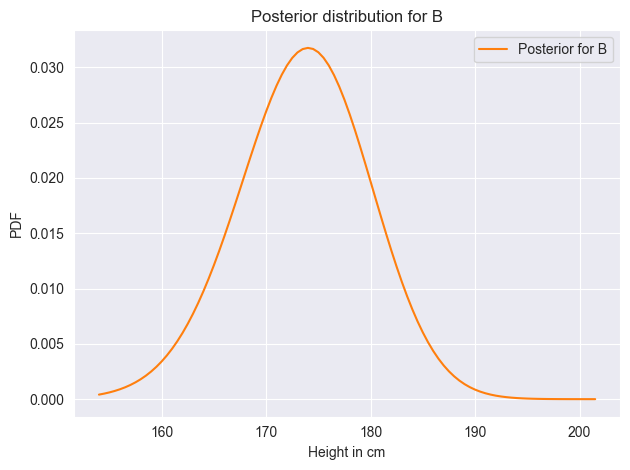

In [19]:
marginal_B = posterior.sum(axis=1)
marginal_B = Pmf(marginal_B)

marginal_B.plot(label='Posterior for B', color='C1')
decorate(
    xlabel='Height in cm',
    ylabel='PDF',
    title='Posterior distribution for B'
)

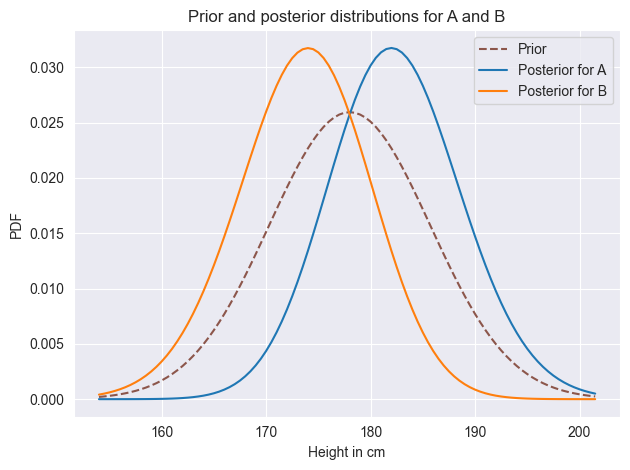

In [20]:
def marginal(joint, axis):
    """Compute a marginal distribution."""
    return Pmf(joint.sum(axis=axis))

marginal_A = marginal(posterior, axis=0)
marginal_B = marginal(posterior, axis=1)

prior.plot(style='--', label='Prior', color='C5')
marginal_A.plot(label='Posterior for A')
marginal_B.plot(label='Posterior for B')
decorate(
    xlabel='Height in cm',
    ylabel='PDF',
    title='Prior and posterior distributions for A and B'
)

In [24]:
print(f"Prior mean: {prior.mean()}")
print(f"Marginal A mean: {marginal_A.mean()}, Marginal B mean: {marginal_B.mean()}")

Prior mean: 177.99516026921506
Marginal A mean: 182.38728123421686, Marginal B mean: 173.60286000233387


In [25]:
print(f"Prior std: {prior.std()}")
print(f"Marginal A std: {marginal_A.std()}, Marginal B std: {marginal_B.std()}")

Prior std: 7.624924796641578
Marginal A std: 6.27046117764547, Marginal B std: 6.280513548175111


## 11.8 Conditional Posteriors

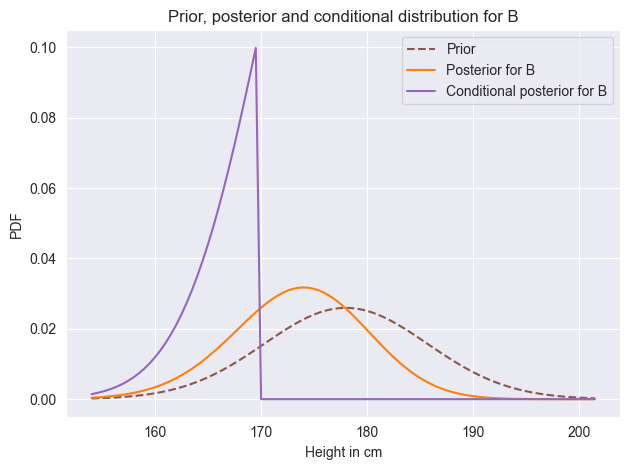

In [26]:
cond_B = posterior[170]  # B's distribution when A is 170 cm
cond_B = Pmf(cond_B)
cond_B.normalize()

prior.plot(style='--', label='Prior', color='C5')
marginal_B.plot(label='Posterior for B', color='C1')
cond_B.plot(
    label='Conditional posterior for B', 
    color='C4'
)

decorate(
    xlabel='Height in cm',
    ylabel='PDF',
    title='Prior, posterior and conditional distribution for B'
)